In [1]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [4]:
data=pd.read_csv("1_k_means_customer_segmentation.csv")
data.head()

,CustomerID,Age,AnnualIncome,SpendingScore,MonthlyVisits,AnnualSpend
0,1,30,28648,70,12,7006
1,2,23,29572,93,9,10543
2,3,28,27848,88,14,5260
3,4,20,28070,76,11,9139
4,5,29,25869,87,11,10865


In [5]:
data.shape

(100, 6)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   CustomerID     100 non-null    int64
 1   Age            100 non-null    int64
 2   AnnualIncome   100 non-null    int64
 3   SpendingScore  100 non-null    int64
 4   MonthlyVisits  100 non-null    int64
 5   AnnualSpend    100 non-null    int64
dtypes: int64(6)
memory usage: 4.8 KB


In [7]:
data.describe()

,CustomerID,Age,AnnualIncome,SpendingScore,MonthlyVisits,AnnualSpend
count,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000
mean,50.500000,38.300000,66879.790000,54.83000,7.440000,20793.700000
std,29.011492,12.757648,28731.344824,26.68827,3.864681,12214.854764
min,1.000000,20.000000,25869.000000,10.00000,1.000000,5260.000000
25%,25.750000,29.000000,38844.250000,29.75000,4.000000,10841.500000
50%,50.500000,34.000000,65743.500000,56.00000,8.000000,18054.500000
75%,75.250000,49.250000,93629.750000,76.00000,10.250000,30160.750000
max,100.000000,60.000000,119261.000000,99.00000,15.000000,49637.000000


In [8]:
data.isnull().sum()

CustomerID       0
Age              0
AnnualIncome     0
SpendingScore    0
MonthlyVisits    0
AnnualSpend      0
dtype: int64

In [9]:
X=data.drop("CustomerID", axis=1)
X.head()

,Age,AnnualIncome,SpendingScore,MonthlyVisits,AnnualSpend
0,30,28648,70,12,7006
1,23,29572,93,9,10543
2,28,27848,88,14,5260
3,20,28070,76,11,9139
4,29,25869,87,11,10865


In [11]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [15]:


wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)   
    wcss.append(kmeans.inertia_)  


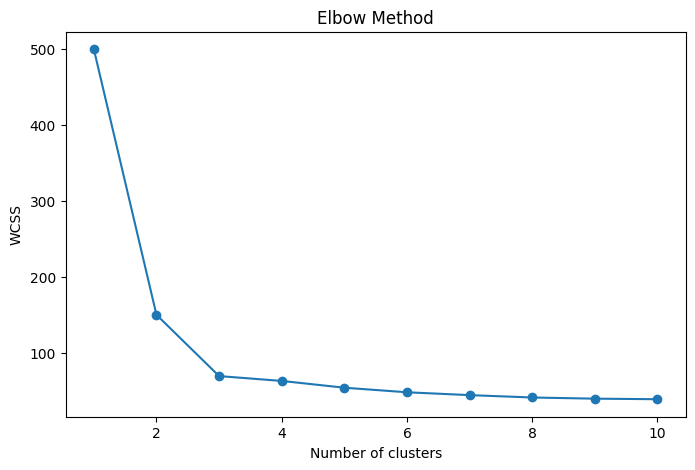

In [16]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11),
         wcss, marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()
           

In [17]:
kmeans=KMeans(n_clusters=3,random_state=42)
kmeans.fit(X_scaled)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [19]:
clusters=kmeans.predict(X_scaled)
clusters

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int32)

In [20]:
data["Cluster"]=clusters
data.head()

,CustomerID,Age,AnnualIncome,SpendingScore,MonthlyVisits,AnnualSpend,Cluster
0,1,30,28648,70,12,7006,2
1,2,23,29572,93,9,10543,2
2,3,28,27848,88,14,5260,2
3,4,20,28070,76,11,9139,2
4,5,29,25869,87,11,10865,2


In [21]:
data["Cluster"].value_counts()

Cluster
2    34
0    33
1    33
Name: count, dtype: int64

In [22]:
kmeans.cluster_centers_

array([[-0.18835401, -0.04263499,  0.04406034, -0.0592615 , -0.25655417],
       [ 1.24877034,  1.21130271, -1.1895379 , -1.04432641,  1.25258006],
       [-1.02922762, -1.13429515,  1.11178704,  1.07112945, -0.96673102]])

In [24]:

centers = scaler.inverse_transform(kmeans.cluster_centers_)

centers = pd.DataFrame(centers, columns=X.columns)

centers


,Age,AnnualIncome,SpendingScore,MonthlyVisits,AnnualSpend
0,35.909091,65660.969697,56.000000,7.212121,17675.636364
1,54.151515,101507.696970,23.242424,3.424242,36017.090909
2,25.235294,34453.323529,84.352941,11.558824,9044.411765


In [25]:
score=silhouette_score(X_scaled,clusters)
print("Silhouette Score:", score)


Silhouette Score: 0.5630203575587325


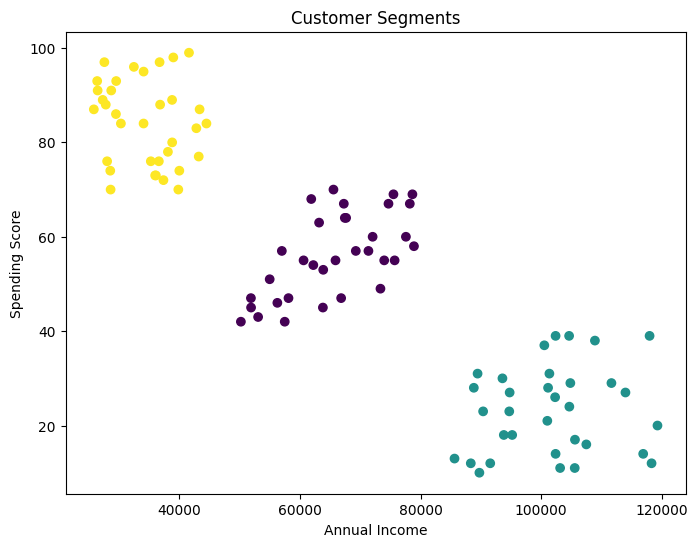

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(data["AnnualIncome"],
            data["SpendingScore"],
            c=data["Cluster"],
            cmap="viridis")   # corrected spelling
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments")
plt.show()


In [31]:
new_customer=[[28,40000,80,12,10000]]
new_customer_scaled = scaler.transform(new_customer)

In [33]:
prediction=kmeans.predict(new_customer_scaled)
print("Predicted Cluster:", prediction[0])

Predicted Cluster: 2


In [34]:
prediction=kmeans.predict(new_customer_scaled)
print("Predicted Cluster:", prediction[0])

Predicted Cluster: 2
